In [1]:
import numpy as np
import scipy
import torch
import torch.nn as nn
from torchdiffeq import odeint as torchodeint
from tqdm import tqdm
import matplotlib.pyplot as plt

import os, sys

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path+"\\code")
from myKANODE import KANODE

In [2]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.mlp = nn.Sequential(
            nn.Linear(2, 256),
            nn.LayerNorm(256),
            nn.Linear(256, 256),
            nn.LayerNorm(256),
            nn.Linear(256, 2)
        )
    def forward(self, x):
        out = self.mlp(x)
        return out

In [3]:
#model = ChebyKAN([2, 10, 2], 4)
model = MLP()

In [4]:
def pred_prey_deriv(X, t, alpha, beta, delta, gamma):
    x=X[0]
    y=X[1]
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dXdt=[dxdt, dydt]
    return dXdt

# alpha, beta, delta, gamma
params = [1.5, 1, 2, 1]
X0 = [0.3, 1.5]

In [5]:
kanODE = KANODE(model, pred_prey_deriv, X0, params, 20, 6, 0.01)

100%|██████████| 10000/10000 [5:15:07<00:00,  1.89s/it] 


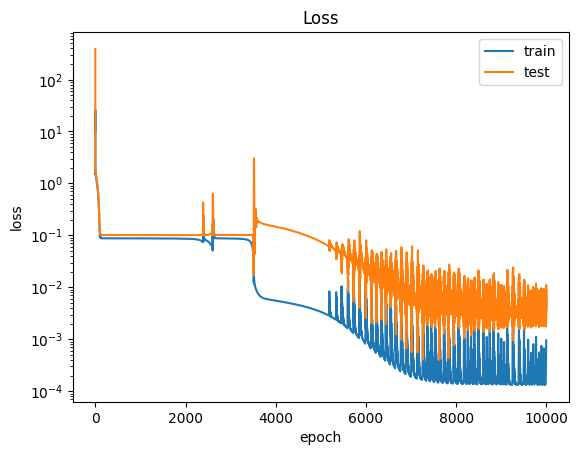

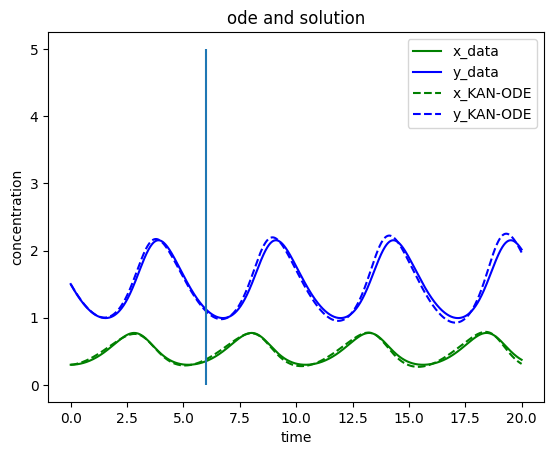

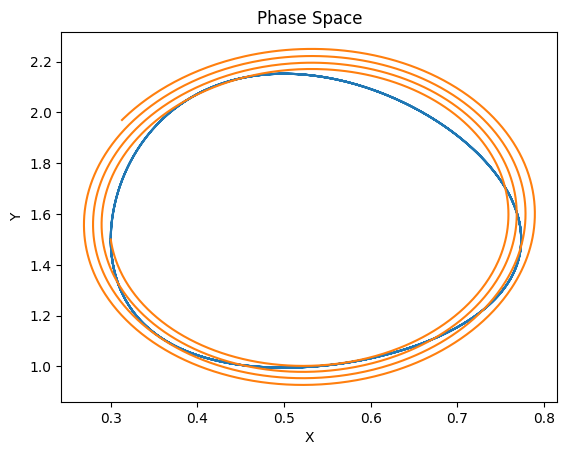

In [6]:
saveDirectory = os.path.join(module_path, "savedModels", "MLP2")
if not os.path.isdir(saveDirectory):
    os.makedirs(saveDirectory)

kanODE.train(-1, solverMethod="rk4", saveDirectory=saveDirectory, saveCooldown=200)
_, solution = kanODE.test(solverMethod="rk4")
kanODE.plotLoss("Loss")
kanODE.plotODE("ode and solution", solution[:, 0, :])
kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])